# Mini Project CRM: ABC Customer Segmentation theo lợi nhuận

## 1. Business Context

Bộ phận Chăm sóc khách hàng và Marketing đang chuẩn bị chương trình tri ân cuối năm. Tuy nhiên, ngân sách chỉ có **500 suất quà đặc biệt**, nên công ty cần xác định nhóm khách hàng quan trọng nhất để ưu tiên chăm sóc.

## 2. Business Questions

1. Nhóm A chiếm bao nhiêu % tổng số khách hàng? Có tuân theo quy luật Pareto không?
2. Nếu chỉ có 500 suất quà đặc biệt, nhóm A có vượt quá số lượng này không?
3. Dựa vào thu nhập và nghề nghiệp, nên đề xuất gì để thu hút thêm khách hàng nhóm A mới?

## 3. Scope dữ liệu

Bài toán chỉ cần phân tích theo khách hàng, lợi nhuận, thu nhập và nghề nghiệp. Vì vậy chỉ dùng 2 bảng:

- `EcomSales.csv`: lấy `RowID`, `OrderID`, `CustomerID`, `Profit`
- `Customer.csv`: lấy `CustomerID`, `FirstName`, `LastName`, `AnnualIncome`, `Occupation`

Không dùng `Product.csv` và `Region.csv` vì yêu cầu bài không phân tích theo sản phẩm hoặc khu vực.


In [ ]:
# 1. Import thư viện và khai báo cấu hình

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# File paths
SALES_PATH = "EcomSales.csv"
CUSTOMER_PATH = "Customer.csv"

# Chỉ chọn các cột cần thiết
SALES_COLS = ["RowID", "OrderID", "CustomerID", "Profit"]
CUSTOMER_COLS = ["CustomerID", "FirstName", "LastName", "AnnualIncome", "Occupation"]

# Business thresholds
A_THRESHOLD = 0.80
B_THRESHOLD = 0.95
GIFT_LIMIT = 500

# Income groups
INCOME_BINS = [0, 40000, 60000, 80000, 100000, 120000, np.inf]
INCOME_LABELS = ["<40k", "40k-60k", "60k-80k", "80k-100k", "100k-120k", ">120k"]


## Data Preprocessing

Trước khi phân tích, kiểm tra nhanh 3 vấn đề cơ bản:

1. Trùng lặp dữ liệu.
2. Missing values.
3. Kiểu dữ liệu.

Nếu dữ liệu không có vấn đề, bước clean data chỉ cần chuẩn hóa nhẹ để phục vụ phân tích.


In [ ]:
# 2. Refactor helper functions

def load_data(sales_path, customer_path):
    """Load only necessary columns for the analysis."""
    sales_df = pd.read_csv(sales_path, usecols=SALES_COLS)
    customer_df = pd.read_csv(customer_path, usecols=CUSTOMER_COLS)
    return sales_df, customer_df


def check_quality(sales_df, customer_df):
    """Check duplicates, missing values and data types."""
    quality_summary = pd.DataFrame({
        "Table": ["sales", "customer"],
        "Rows": [sales_df.shape[0], customer_df.shape[0]],
        "Columns": [sales_df.shape[1], customer_df.shape[1]],
        "Duplicated rows": [sales_df.duplicated().sum(), customer_df.duplicated().sum()],
        "Duplicated key": [
            sales_df["RowID"].duplicated().sum(),
            customer_df["CustomerID"].duplicated().sum()
        ]
    })

    missing_sales = sales_df.isna().sum().to_frame("Missing Count")
    missing_customer = customer_df.isna().sum().to_frame("Missing Count")

    dtype_sales = sales_df.dtypes.to_frame("Data Type")
    dtype_customer = customer_df.dtypes.to_frame("Data Type")

    return quality_summary, missing_sales, missing_customer, dtype_sales, dtype_customer


def clean_data(sales_df, customer_df):
    """Light cleaning because basic data quality check shows no major issue."""
    sales_clean = sales_df.copy()
    customer_clean = customer_df.copy()

    for col in sales_clean.select_dtypes(include="object").columns:
        sales_clean[col] = sales_clean[col].astype(str).str.strip()

    for col in customer_clean.select_dtypes(include="object").columns:
        customer_clean[col] = customer_clean[col].astype(str).str.strip()

    return sales_clean, customer_clean


def build_customer_profit(sales_df, customer_df):
    """Aggregate profit by customer and enrich with customer profile."""
    customer_profit_df = sales_df.groupby("CustomerID", as_index=False).agg(
        TotalProfit=("Profit", "sum"),
        NumberOfOrders=("OrderID", "nunique"),
        TransactionRows=("RowID", "count")
    )

    customer_profit_df = customer_profit_df.merge(
        customer_df,
        on="CustomerID",
        how="left"
    )

    customer_profit_df["CustomerName"] = (
        customer_profit_df["FirstName"] + " " + customer_profit_df["LastName"]
    ).str.strip()

    return customer_profit_df


def run_abc_segmentation(customer_profit_df):
    """Segment customers into A/B/C based on cumulative net profit contribution."""
    result = customer_profit_df.sort_values(
        "TotalProfit",
        ascending=False
    ).reset_index(drop=True)

    total_profit = result["TotalProfit"].sum()
    result["CumProfit"] = result["TotalProfit"].cumsum()
    result["CumProfitPct"] = result["CumProfit"] / total_profit
    result["PrevCumProfitPct"] = result["CumProfitPct"].shift(fill_value=0)

    result["ABC_Group"] = np.select(
        [
            result["PrevCumProfitPct"] < A_THRESHOLD,
            result["PrevCumProfitPct"] < B_THRESHOLD
        ],
        ["A", "B"],
        default="C"
    )

    return result


def summarize_abc(customer_profit_df):
    """Create ABC summary table and key metrics."""
    summary = customer_profit_df.groupby("ABC_Group", as_index=False).agg(
        CustomerCount=("CustomerID", "count"),
        TotalProfit=("TotalProfit", "sum"),
        AvgProfitPerCustomer=("TotalProfit", "mean"),
        AvgIncome=("AnnualIncome", "mean")
    )

    summary["CustomerPct"] = summary["CustomerCount"] / customer_profit_df["CustomerID"].nunique()
    summary["ProfitPct"] = summary["TotalProfit"] / customer_profit_df["TotalProfit"].sum()

    a_row = summary.loc[summary["ABC_Group"] == "A"].iloc[0]

    metrics = {
        "a_count": int(a_row["CustomerCount"]),
        "total_customers": int(customer_profit_df["CustomerID"].nunique()),
        "a_customer_pct": float(a_row["CustomerPct"]),
        "a_profit_pct": float(a_row["ProfitPct"]),
        "gift_limit": GIFT_LIMIT,
        "gift_gap": int(a_row["CustomerCount"] - GIFT_LIMIT)
    }

    return summary, metrics


def create_profile_tables(customer_profit_df):
    """Create income and occupation profile tables for Group A."""
    customer_profit_df = customer_profit_df.copy()

    customer_profit_df["IncomeGroup"] = pd.cut(
        customer_profit_df["AnnualIncome"],
        bins=INCOME_BINS,
        labels=INCOME_LABELS,
        include_lowest=True
    )

    a_customers = customer_profit_df[customer_profit_df["ABC_Group"] == "A"].copy()

    income_profile = (
        a_customers["IncomeGroup"]
        .value_counts()
        .sort_index()
        .reset_index()
    )
    income_profile.columns = ["IncomeGroup", "CustomerCount"]

    occupation_profile = (
        a_customers["Occupation"]
        .value_counts()
        .reset_index()
    )
    occupation_profile.columns = ["Occupation", "CustomerCount"]

    return customer_profit_df, a_customers, income_profile, occupation_profile


def compare_group_a_vs_all(customer_profit_df, a_customers):
    """Compare Group A profile with all customers using index ratio."""
    occupation_compare = pd.DataFrame({
        "A_Count": a_customers["Occupation"].value_counts(),
        "All_Count": customer_profit_df["Occupation"].value_counts()
    }).fillna(0)

    occupation_compare["A_Pct"] = occupation_compare["A_Count"] / occupation_compare["A_Count"].sum()
    occupation_compare["All_Pct"] = occupation_compare["All_Count"] / occupation_compare["All_Count"].sum()
    occupation_compare["Index_A_vs_All"] = occupation_compare["A_Pct"] / occupation_compare["All_Pct"]
    occupation_compare = occupation_compare.sort_values("A_Count", ascending=False)

    income_compare = pd.DataFrame({
        "A_Count": a_customers["IncomeGroup"].value_counts(),
        "All_Count": customer_profit_df["IncomeGroup"].value_counts()
    }).fillna(0)

    income_compare["A_Pct"] = income_compare["A_Count"] / income_compare["A_Count"].sum()
    income_compare["All_Pct"] = income_compare["All_Count"] / income_compare["All_Count"].sum()
    income_compare["Index_A_vs_All"] = income_compare["A_Pct"] / income_compare["All_Pct"]
    income_compare = income_compare.sort_index()

    return occupation_compare, income_compare


In [ ]:
# 3. Load data

sales, customer = load_data(SALES_PATH, CUSTOMER_PATH)

print("Sales shape:", sales.shape)
print("Customer shape:", customer.shape)

display(sales.head())
display(customer.head())


Sales shape: (51290, 4)
Customer shape: (17415, 5)


,RowID,OrderID,CustomerID,Profit
0,25221,IN-2012-TH211151-41003,TH-211151,208.00
1,29464,ID-2013-BD116051-41518,BD-116051,10.00
2,27311,IN-2015-TS212051-42173,TS-212051,8.00
3,28882,IN-2014-SU206651-41899,SU-206651,55.60
4,27992,IN-2015-GM144551-42217,GM-144551,0.60


,CustomerID,FirstName,LastName,AnnualIncome,Occupation
0,TH-211151,Jon,Huang,90000,Professional
1,BD-116051,Eugene,Torres,60000,Professional
2,TS-212051,Ruben,Zhu,60000,Professional
3,SU-206651,Christy,Johnson,70000,Professional
4,GM-144551,Elizabeth,Ruiz,80000,Professional


In [ ]:
# 4. Data quality check

quality_summary, missing_sales, missing_customer, dtype_sales, dtype_customer = check_quality(sales, customer)

display(quality_summary)

print("Missing values - sales")
display(missing_sales)

print("Missing values - customer")
display(missing_customer)

print("Data types - sales")
display(dtype_sales)

print("Data types - customer")
display(dtype_customer)


,Table,Rows,Columns,Duplicated rows,Duplicated key
0,sales,51290,4,0,0
1,customer,17415,5,0,0


Missing values - sales


,Missing Count
RowID,0
OrderID,0
CustomerID,0
Profit,0


Missing values - customer


,Missing Count
CustomerID,0
FirstName,0
LastName,0
AnnualIncome,0
Occupation,0


Data types - sales


,Data Type
RowID,int64
OrderID,object
CustomerID,object
Profit,float64


Data types - customer


,Data Type
CustomerID,object
FirstName,object
LastName,object
AnnualIncome,int64
Occupation,object


## Nhận xét Data Preprocessing

Sau khi kiểm tra, dữ liệu không có vấn đề về trùng lặp, missing values và kiểu dữ liệu.

Vì vậy, bài phân tích không cần xử lý missing hay xóa dữ liệu. Ở bước clean data, ta chỉ chuẩn hóa nhẹ các cột text để tránh lỗi khoảng trắng khi join dữ liệu.

Lưu ý: `Profit` âm không bị xóa vì đây là thông tin kinh doanh quan trọng. Nó phản ánh giao dịch hoặc khách hàng làm giảm lợi nhuận.


In [ ]:
# 5. Clean data nhẹ và tạo customer-level dataset

sales_clean, customer_clean = clean_data(sales, customer)

negative_transaction_count = (sales_clean["Profit"] < 0).sum()

customer_profit = build_customer_profit(sales_clean, customer_clean)
negative_customer_count = (customer_profit["TotalProfit"] <= 0).sum()

print("Số dòng giao dịch có Profit âm:", negative_transaction_count)
print("Số khách hàng có TotalProfit <= 0:", negative_customer_count)

display(customer_profit.head())


Số dòng giao dịch có Profit âm: 11041
Số khách hàng có TotalProfit <= 0: 4019


,CustomerID,TotalProfit,NumberOfOrders,TransactionRows,FirstName,LastName,AnnualIncome,Occupation,CustomerName
0,AA-10315102,-163.70,2,6,Bryant,Vazquez,20000,Clerical,Bryant Vazquez
1,AA-10315120,31.50,1,1,Jon,Rubio,20000,Clerical,Jon Rubio
2,AA-10315139,135.25,4,13,Jésus,Hernandez,30000,Clerical,Jésus Hernandez
3,AA-103151402,10.70,2,6,Marcus,Taylor,40000,Skilled Manual,Marcus Taylor
4,AA-103151404,39.50,2,3,Jesse,Dominguez,40000,Skilled Manual,Jesse Dominguez


## ABC Segmentation

Ta phân loại khách hàng dựa trên tổng lợi nhuận ròng (`TotalProfit`) mà mỗi khách hàng mang lại.

Logic phân nhóm:

- **A**: nhóm khách hàng đầu tiên tạo ra khoảng 80% tổng lợi nhuận.
- **B**: nhóm khách hàng tiếp theo tạo ra đến khoảng 95% tổng lợi nhuận.
- **C**: nhóm khách hàng còn lại.

Vì dữ liệu có thể có Profit âm, đường lợi nhuận tích lũy có thể vượt 100% trước khi quay về 100% ở cuối biểu đồ. Đây không phải lỗi code, mà là đặc điểm thực tế của dữ liệu lợi nhuận ròng.


In [ ]:
# 6. Chạy ABC segmentation và tổng hợp kết quả

customer_profit = run_abc_segmentation(customer_profit)
abc_summary, metrics = summarize_abc(customer_profit)

display(abc_summary)

print(f"Nhóm A có {metrics['a_count']:,} khách hàng.")
print(f"Nhóm A chiếm {metrics['a_customer_pct']:.2%} tổng số khách hàng.")
print(f"Nhóm A tạo ra {metrics['a_profit_pct']:.2%} tổng lợi nhuận.")

if metrics["a_customer_pct"] <= 0.20:
    print("Kết luận: Có xu hướng tuân theo quy luật Pareto.")
else:
    print("Kết luận: Nhóm A tạo ra khoảng 80% lợi nhuận nhưng chiếm hơn 20% khách hàng, nên Pareto không quá rõ.")


,ABC_Group,CustomerCount,TotalProfit,AvgProfitPerCustomer,AvgIncome,CustomerPct,ProfitPct
0,A,2255,"852,405.04",378.01,"56,665.19",0.13,0.80
1,B,1217,"159,773.02",131.28,"55,990.14",0.07,0.15
2,C,13943,"53,235.58",3.82,"57,380.76",0.80,0.05


Nhóm A có 2,255 khách hàng.
Nhóm A chiếm 12.95% tổng số khách hàng.
Nhóm A tạo ra 80.01% tổng lợi nhuận.
Kết luận: Có xu hướng tuân theo quy luật Pareto.


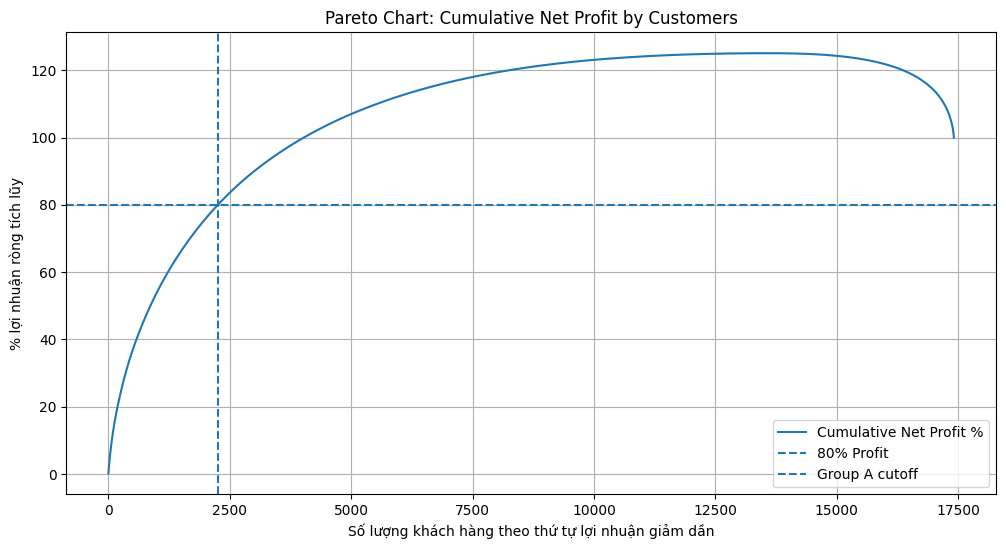

Ghi chú: Nếu đường tích lũy vượt 100%, nguyên nhân là dữ liệu có khách hàng/giao dịch Profit âm.
Các khách hàng Profit âm nằm cuối danh sách sẽ kéo lợi nhuận tích lũy quay về 100%.


In [ ]:
# 7. Biểu đồ Pareto

plt.figure(figsize=(12, 6))

x = np.arange(1, len(customer_profit) + 1)

plt.plot(x, customer_profit["CumProfitPct"] * 100, label="Cumulative Net Profit %")
plt.axhline(80, linestyle="--", label="80% Profit")
plt.axvline(metrics["a_count"], linestyle="--", label="Group A cutoff")

plt.title("Pareto Chart: Cumulative Net Profit by Customers")
plt.xlabel("Số lượng khách hàng theo thứ tự lợi nhuận giảm dần")
plt.ylabel("% lợi nhuận ròng tích lũy")
plt.legend()
plt.grid(True)
plt.show()

print("Ghi chú: Nếu đường tích lũy vượt 100%, nguyên nhân là dữ liệu có khách hàng/giao dịch Profit âm.")
print("Các khách hàng Profit âm nằm cuối danh sách sẽ kéo lợi nhuận tích lũy quay về 100%.")


## Kiểm tra constraint 500 suất quà

Đây là phần quan trọng nhất trong yêu cầu adhoc.

Nếu nhóm A lớn hơn 500 khách hàng, công ty không thể allocate quà cho toàn bộ nhóm A. Khi đó, cần recommend ngược lại rằng business team nên bổ sung thêm criteria để lọc danh sách nhận quà.


In [ ]:
# 8. Kiểm tra 500 suất quà và tạo danh sách VIP

if metrics["a_count"] > GIFT_LIMIT:
    over_ratio = metrics["a_count"] / GIFT_LIMIT

    print(f"Có. Nhóm A có {metrics['a_count']:,} khách hàng, vượt quá {GIFT_LIMIT:,} suất quà.")
    print(f"Số lượng khách hàng nhóm A lớn gấp {over_ratio:.1f} lần số quà hiện có.")
    print(f"Số khách vượt ngân sách: {metrics['gift_gap']:,} khách.")
    print("\nRecommendation:")
    print("- Không nên tặng toàn bộ nhóm A vì vượt ngân sách.")
    print("- Nên bổ sung thêm criteria để lọc danh sách nhận quà.")
    print("- Criteria gợi ý: TotalProfit cao nhất, số đơn hàng, tần suất mua hoặc nhóm khách hàng chiến lược.")
else:
    print(f"Không. Nhóm A có {metrics['a_count']:,} khách hàng, không vượt quá {GIFT_LIMIT:,} suất quà.")

vip_500 = customer_profit[customer_profit["ABC_Group"] == "A"].head(GIFT_LIMIT)

display(vip_500[[
    "CustomerID",
    "CustomerName",
    "TotalProfit",
    "NumberOfOrders",
    "AnnualIncome",
    "Occupation"
]].head(10))


Có. Nhóm A có 2,255 khách hàng, vượt quá 500 suất quà.
Số lượng khách hàng nhóm A lớn gấp 4.5 lần số quà hiện có.
Số khách vượt ngân sách: 1,755 khách.

Recommendation:
- Không nên tặng toàn bộ nhóm A vì vượt ngân sách.
- Nên bổ sung thêm criteria để lọc danh sách nhận quà.
- Criteria gợi ý: TotalProfit cao nhất, số đơn hàng, tần suất mua hoặc nhóm khách hàng chiến lược.


,CustomerID,CustomerName,TotalProfit,NumberOfOrders,AnnualIncome,Occupation
0,AR-1082564,Joanna Sun,"2,625.30",2,40000,Skilled Manual
1,LS-172001402,Katelyn Gutierrez,"2,429.40",2,70000,Skilled Manual
2,MY-1829527,Mitchell Jimenez,"2,165.00",2,30000,Clerical
3,ML-73952,Bethany Ramos,"2,156.00",1,10000,Clerical
4,YS-2188093,Billy Navarro,"2,095.90",2,90000,Professional
5,EH-1376527,Thomas Martinez,"2,089.10",2,60000,Skilled Manual
6,ON-1871545,Garrett Young,"2,071.95",5,30000,Professional
7,GH-1448545,Gilbert Raji,"1,985.20",3,90000,Professional
8,SC-2077058,Katherine Cook,"1,874.75",4,70000,Skilled Manual
9,SP-2054558,Tommy Harris,"1,849.15",2,10000,Manual


## Phân tích chân dung nhóm A

Sau khi xác định nhóm A, ta phân tích thêm `AnnualIncome` và `Occupation` để hiểu nhóm khách hàng giá trị cao là ai.

Mục tiêu không chỉ là mô tả nhóm A hiện tại, mà còn tìm insight để Marketing có thể thu hút thêm khách hàng tương tự.


Income profile - Group A


,IncomeGroup,CustomerCount
0,<40k,975
1,40k-60k,464
2,60k-80k,473
3,80k-100k,170
4,100k-120k,85
5,>120k,88


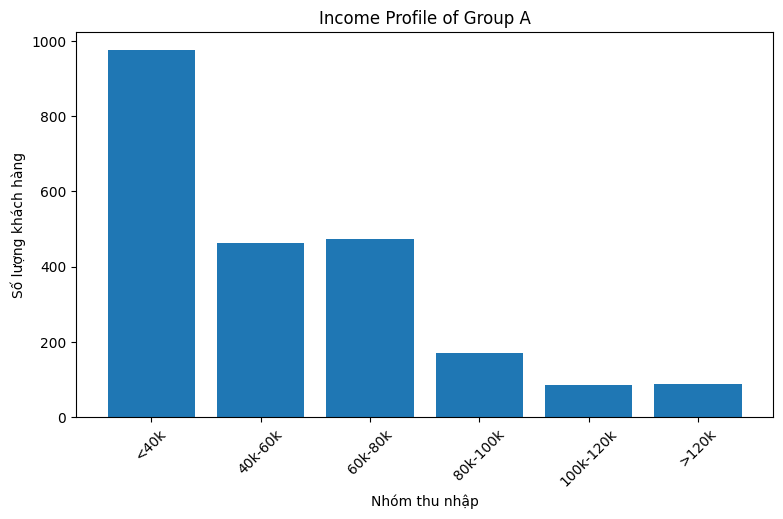

Occupation profile - Group A


,Occupation,CustomerCount
0,Professional,668
1,Skilled Manual,563
2,Clerical,365
3,Management,361
4,Manual,298


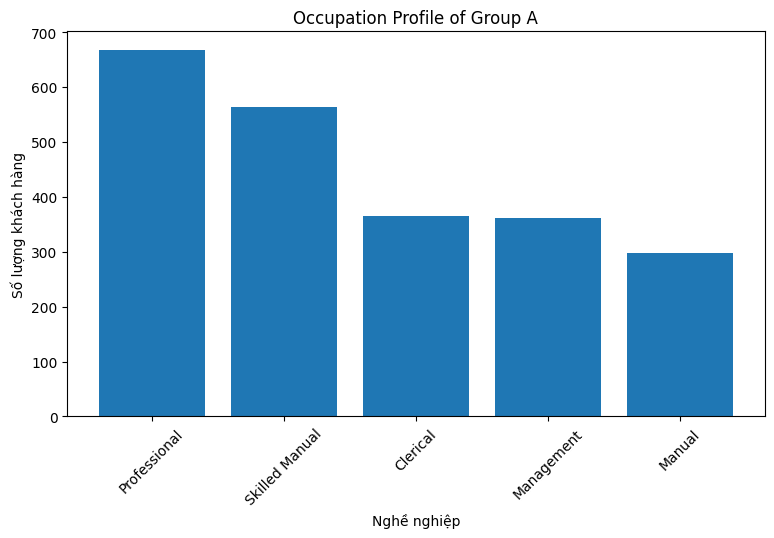

In [ ]:
# 9. Phân tích nhóm A theo thu nhập và nghề nghiệp

customer_profit, a_customers, income_profile, occupation_profile = create_profile_tables(customer_profit)

print("Income profile - Group A")
display(income_profile)

plt.figure(figsize=(9, 5))
plt.bar(income_profile["IncomeGroup"].astype(str), income_profile["CustomerCount"])
plt.title("Income Profile of Group A")
plt.xlabel("Nhóm thu nhập")
plt.ylabel("Số lượng khách hàng")
plt.xticks(rotation=45)
plt.show()

print("Occupation profile - Group A")
display(occupation_profile)

plt.figure(figsize=(9, 5))
plt.bar(occupation_profile["Occupation"], occupation_profile["CustomerCount"])
plt.title("Occupation Profile of Group A")
plt.xlabel("Nghề nghiệp")
plt.ylabel("Số lượng khách hàng")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# 10. So sánh nhóm A với toàn bộ khách hàng

occupation_compare, income_compare = compare_group_a_vs_all(customer_profit, a_customers)

print("Occupation comparison: Group A vs All customers")
display(occupation_compare)

print("Income comparison: Group A vs All customers")
display(income_compare)

print("Cách đọc Index_A_vs_All:")
print("- > 1: nhóm đó xuất hiện trong nhóm A nhiều hơn mặt bằng chung.")
print("- = 1: tương đương mặt bằng chung.")
print("- < 1: nhóm đó ít xuất hiện trong nhóm A hơn mặt bằng chung.")


Occupation comparison: Group A vs All customers


,A_Count,All_Count,A_Pct,All_Pct,Index_A_vs_All
Occupation,,,,,
Professional,668,5176,0.30,0.30,1.00
Skilled Manual,563,4321,0.25,0.25,1.01
Clerical,365,2750,0.16,0.16,1.03
Management,361,2887,0.16,0.17,0.97
Manual,298,2281,0.13,0.13,1.01


Income comparison: Group A vs All customers


,A_Count,All_Count,A_Pct,All_Pct,Index_A_vs_All
IncomeGroup,,,,,
<40k,975,7498,0.43,0.43,1.00
40k-60k,464,3579,0.21,0.21,1.00
60k-80k,473,3499,0.21,0.20,1.04
80k-100k,170,1321,0.08,0.08,0.99
100k-120k,85,754,0.04,0.04,0.87
>120k,88,764,0.04,0.04,0.89


Cách đọc Index_A_vs_All:
- > 1: nhóm đó xuất hiện trong nhóm A nhiều hơn mặt bằng chung.
- = 1: tương đương mặt bằng chung.
- < 1: nhóm đó ít xuất hiện trong nhóm A hơn mặt bằng chung.


## Insight & Recommendation

Phần này chuyển kết quả phân tích thành đề xuất kinh doanh.

Thay vì chỉ trả lời “có bao nhiêu khách hàng nhóm A”, ta cần nói rõ business nên làm gì tiếp theo, đặc biệt khi constraint 500 phần quà không đủ cho toàn bộ nhóm A.


In [ ]:
# 11. Tạo recommendation tự động từ kết quả

top_occupations = occupation_compare.sort_values("A_Count", ascending=False).head(3)
top_income_groups = income_compare.sort_values("A_Count", ascending=False).head(3)

print("=== Executive Summary ===")

print(f"1. Nhóm A có {metrics['a_count']:,} khách hàng, chiếm {metrics['a_customer_pct']:.2%} tổng số khách hàng.")
print(f"2. Nhóm A tạo ra {metrics['a_profit_pct']:.2%} tổng lợi nhuận.")

if metrics["a_customer_pct"] <= 0.20:
    print("3. Dữ liệu có xu hướng Pareto: một nhóm nhỏ khách hàng tạo ra phần lớn lợi nhuận.")
else:
    print("3. Dữ liệu có xu hướng tập trung lợi nhuận, nhưng chưa phải Pareto 80/20 rõ ràng.")

if metrics["a_count"] > GIFT_LIMIT:
    print(f"4. Constraint 500 phần quà không đủ vì nhóm A lớn gấp {metrics['a_count'] / GIFT_LIMIT:.1f} lần số quà.")
    print("5. Nên bổ sung thêm tiêu chí lọc để chọn Top 500 khách hàng phù hợp nhất.")
else:
    print("4. Constraint 500 phần quà đủ cho toàn bộ nhóm A.")

print("\nNhóm nghề nghiệp nên ưu tiên:")
for occ in top_occupations.index:
    print(f"- {occ}: chiếm {top_occupations.loc[occ, 'A_Pct']:.2%} trong nhóm A")

print("\nNhóm thu nhập nên ưu tiên:")
for income in top_income_groups.index:
    print(f"- {income}: chiếm {top_income_groups.loc[income, 'A_Pct']:.2%} trong nhóm A")

print("\nRecommendation:")
print("- Ưu tiên Top 500 khách hàng có TotalProfit cao nhất để nhận quà đặc biệt.")
print("- Nếu business muốn công bằng hơn, có thể bổ sung NumberOfOrders làm tiêu chí phụ.")
print("- Dùng nhóm A hiện tại để tạo lookalike audience cho chiến dịch Marketing.")
print("- Không nên target chỉ bằng thu nhập/nghề nghiệp; nên kết hợp thêm hành vi mua hàng và lợi nhuận thực tế.")
print("- Theo dõi riêng nhóm khách hàng có TotalProfit âm để tìm nguyên nhân gây lỗ.")


=== Executive Summary ===
1. Nhóm A có 2,255 khách hàng, chiếm 12.95% tổng số khách hàng.
2. Nhóm A tạo ra 80.01% tổng lợi nhuận.
3. Dữ liệu có xu hướng Pareto: một nhóm nhỏ khách hàng tạo ra phần lớn lợi nhuận.
4. Constraint 500 phần quà không đủ vì nhóm A lớn gấp 4.5 lần số quà.
5. Nên bổ sung thêm tiêu chí lọc để chọn Top 500 khách hàng phù hợp nhất.

Nhóm nghề nghiệp nên ưu tiên:
- Professional: chiếm 29.62% trong nhóm A
- Skilled Manual: chiếm 24.97% trong nhóm A
- Clerical: chiếm 16.19% trong nhóm A

Nhóm thu nhập nên ưu tiên:
- <40k: chiếm 43.24% trong nhóm A
- 60k-80k: chiếm 20.98% trong nhóm A
- 40k-60k: chiếm 20.58% trong nhóm A

Recommendation:
- Ưu tiên Top 500 khách hàng có TotalProfit cao nhất để nhận quà đặc biệt.
- Nếu business muốn công bằng hơn, có thể bổ sung NumberOfOrders làm tiêu chí phụ.
- Dùng nhóm A hiện tại để tạo lookalike audience cho chiến dịch Marketing.
- Không nên target chỉ bằng thu nhập/nghề nghiệp; nên kết hợp thêm hành vi mua hàng và lợi nhuận thực t

# Final Conclusion

Nhóm A là nhóm khách hàng có giá trị cao nhất trong CRM vì tạo ra phần lớn lợi nhuận cho công ty. Tuy nhiên, số lượng khách hàng nhóm A lớn hơn nhiều so với constraint 500 suất quà, nên business không thể phân bổ quà cho toàn bộ nhóm này.

Do đó, đề xuất hợp lý là:

1. Dùng ABC segmentation để xác định tập khách hàng tiềm năng.
2. Lọc tiếp Top 500 bằng các tiêu chí bổ sung như `TotalProfit`, `NumberOfOrders` hoặc tần suất mua.
3. Dùng profile của nhóm A theo thu nhập và nghề nghiệp để xây dựng chiến dịch lookalike audience.
4. Không bỏ qua nhóm khách hàng có Profit âm, vì đây là tín hiệu cần phân tích thêm để tối ưu lợi nhuận.
